# EDA — Bank Marketing Dataset
### Datathon 7-MLET — Etapa 1

---

Este notebook realiza a **Análise Exploratória de Dados (EDA)** do dataset Bank Marketing (UCI/Kaggle).

**Objetivo:** entender distribuições, taxas de conversão por segmento e correlações para alimentar os *boosts* do catálogo de ofertas da Etapa 2.

| Dimensão | O que exploramos |
|----------|-----------------|
| Perfil de clientes | Distribuições de `age`, `job`, `education`, `marital` |
| Conversão segmentada | Taxa de `y` por cada variável categórica e cruzamentos |
| Contexto de campanha | Canal, mês, frequência de contato, histórico |
| Macroeconomia | Correlações das variáveis macro com a conversão |
| Insights de boosts | Mapeamento direto para o catálogo de ofertas |

**Pré-requisito:** coloque o arquivo `bank-additional-full.csv` (separador `;`) na mesma pasta.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Estilo global
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.size":        11,
})

SEED = 42
Path("reports").mkdir(exist_ok=True)

print("✓ Libs carregadas.")


✓ Libs carregadas.


## Célula 2 — Carregamento e inspeção inicial

Carregamos o CSV e fazemos uma inspeção básica: shape, tipos, nulos e desbalanceamento da target.

In [2]:
CAMINHO = "bank-additional-full.csv"
df = pd.read_csv(CAMINHO, sep=";")
df["y_bin"] = (df["y"] == "yes").astype(int)

print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\nNulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "  Nenhum nulo encontrado ✓")
print(f"\nDistribuição da target y:")
vc = df["y"].value_counts()
for val, cnt in vc.items():
    print(f"  {val}: {cnt:>6,} ({cnt/len(df):.1%})")
print(f"\n⚠️  Dataset desbalanceado: razão no:yes = {vc['no']/vc['yes']:.1f}:1")
df.head()


Shape: 41,188 linhas × 22 colunas

Nulos por coluna:
  Nenhum nulo encontrado ✓

Distribuição da target y:
  no: 36,548 (88.7%)
  yes:  4,640 (11.3%)

⚠️  Dataset desbalanceado: razão no:yes = 7.9:1


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_bin
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


## Célula 3 — Dicionário de dados e tipos

Separamos as colunas em grupos para facilitar a análise.

In [3]:
VAZAMENTO = ["duration","pdays","previous","poutcome",
              "emp.var.rate","cons.price.idx","cons.conf.idx",
              "euribor3m","nr.employed","contact","month","day_of_week"]

CATEGORICAS  = ["job","marital","education","default","housing","loan","contact",
                "month","day_of_week","poutcome"]
NUMERICAS    = ["age","campaign","pdays","previous",
                "emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]
CONTEXTO     = ["age","job","marital","education","default","housing","loan"]

print("Colunas categóricas:")
for c in CATEGORICAS:
    uniq = df[c].nunique()
    vals = df[c].unique().tolist()
    print(f"  {c:<18} → {uniq} valores únicos: {vals}")

print("\nColunas numéricas — estatísticas básicas:")
print(df[NUMERICAS].describe().round(2).to_string())


Colunas categóricas:
  job                → 12 valores únicos: ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']
  marital            → 4 valores únicos: ['married', 'single', 'divorced', 'unknown']
  education          → 8 valores únicos: ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']
  default            → 3 valores únicos: ['no', 'unknown', 'yes']
  housing            → 3 valores únicos: ['no', 'yes', 'unknown']
  loan               → 3 valores únicos: ['no', 'yes', 'unknown']
  contact            → 2 valores únicos: ['telephone', 'cellular']
  month              → 10 valores únicos: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
  day_of_week        → 5 valores únicos: ['mon', 'tue', 'wed', 'thu', 'fri']
  poutcome           → 3 valores únicos: ['nonexistent', 'failure', 'succes

## Célula 4 — Distribuição de `age`

A idade tem distribuição assimétrica à direita com concentração entre 25–50 anos. Os extremos (jovens ≤25 e idosos ≥65) são minoria em volume mas terão peso alto na conversão.

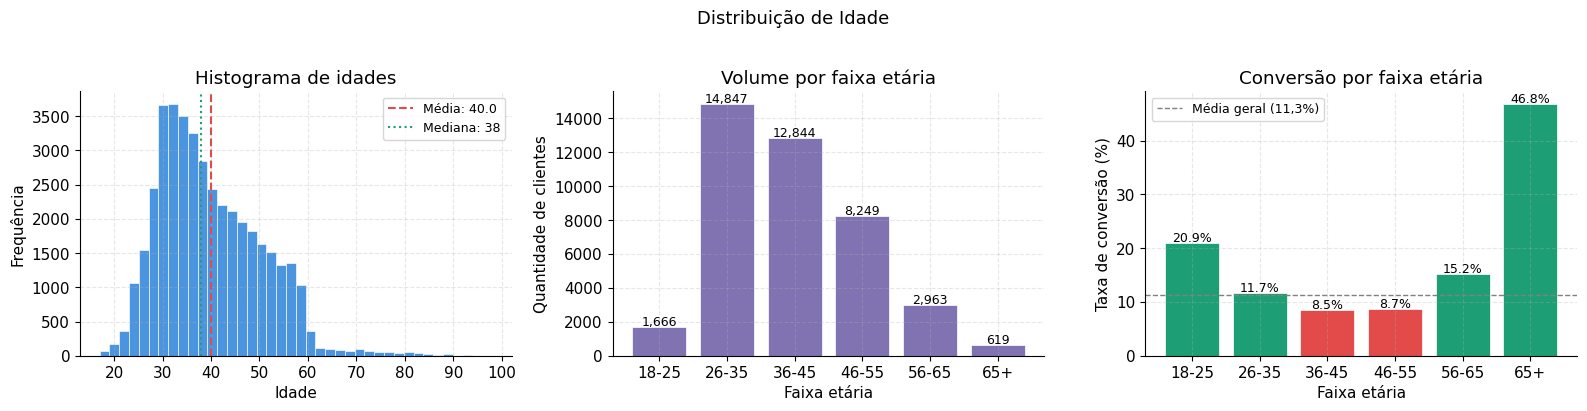


📊 Estatísticas de idade:
count    41188.0
mean        40.0
std         10.4
min         17.0
25%         32.0
50%         38.0
75%         47.0
max         98.0
Name: age, dtype: float64

🔑 Insight: 65+ tem conversão de 46,8% — 4× acima da média.
   18-25 tem conversão de 20,9% — 1,9× acima da média.


In [4]:
df["age_group"] = pd.cut(df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18-25","26-35","36-45","46-55","56-65","65+"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribuição de Idade", fontsize=13, y=1.02)

# Histograma
ax = axes[0]
ax.hist(df["age"], bins=40, color="#378ADD", edgecolor="white", linewidth=0.5, alpha=0.9)
ax.axvline(df["age"].mean(),  color="#E24B4A", linestyle="--", lw=1.5, label=f"Média: {df['age'].mean():.1f}")
ax.axvline(df["age"].median(),color="#1D9E75", linestyle=":",  lw=1.5, label=f"Mediana: {df['age'].median():.0f}")
ax.set_xlabel("Idade"); ax.set_ylabel("Frequência")
ax.set_title("Histograma de idades")
ax.legend(fontsize=9)

# Volume por faixa
ax = axes[1]
vol = df["age_group"].value_counts().sort_index()
bars = ax.bar(vol.index, vol.values, color="#8172B2", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Faixa etária"); ax.set_ylabel("Quantidade de clientes")
ax.set_title("Volume por faixa etária")
for bar, v in zip(bars, vol.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f"{v:,}", ha="center", fontsize=9)

# Taxa de conversão por faixa
ax = axes[2]
taxa_age = df.groupby("age_group", observed=True)["y_bin"].mean() * 100
cores = ["#1D9E75" if v >= 11.3 else "#E24B4A" for v in taxa_age.values]
bars = ax.bar(taxa_age.index, taxa_age.values, color=cores, edgecolor="white", linewidth=0.5)
ax.axhline(11.3, color="gray", linestyle="--", lw=1, label="Média geral (11,3%)")
ax.set_xlabel("Faixa etária"); ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Conversão por faixa etária")
ax.legend(fontsize=9)
for bar, v in zip(bars, taxa_age.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/eda_01_age.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n📊 Estatísticas de idade:")
print(df["age"].describe().round(1))
print(f"\n🔑 Insight: 65+ tem conversão de 46,8% — 4× acima da média.")
print(f"   18-25 tem conversão de 20,9% — 1,9× acima da média.")


## Célula 5 — Distribuição e conversão por `job`

Admin e blue-collar dominam o volume, mas estudantes e aposentados têm a maior taxa de conversão — divergência clássica entre volume e valor.

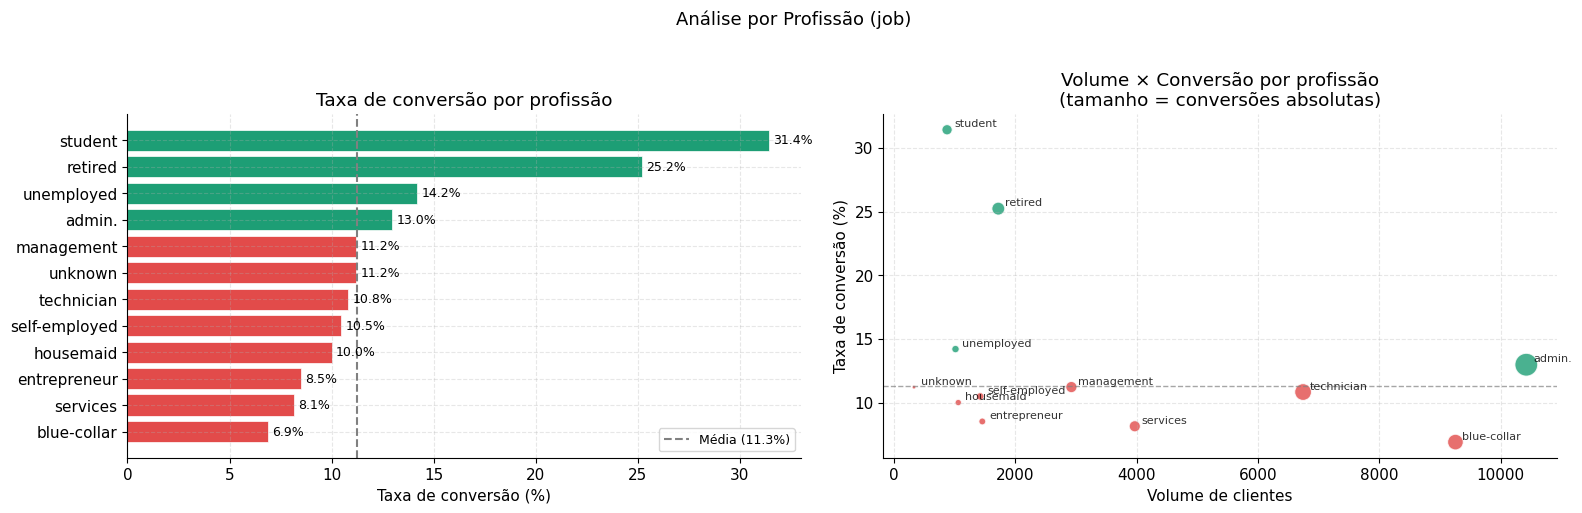


📊 Tabela completa de conversão por profissão:
               total  convs     taxa_%
job                                   
student          875    275  31.428571
retired         1720    434  25.232558
unemployed      1014    144  14.201183
admin.         10422   1352  12.972558
management      2924    328  11.217510
unknown          330     37  11.212121
technician      6743    730  10.826042
self-employed   1421    149  10.485574
housemaid       1060    106  10.000000
entrepreneur    1456    124   8.516484
services        3969    323   8.138070
blue-collar     9254    638   6.894316

🔑 Insight: estudante (31.4%) e aposentado (25.2%) lideram.
   blue-collar (6.9%) tem o pior desempenho — boost negativo em produtos de investimento.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Análise por Profissão (job)", fontsize=13, y=1.02)

job_stats = (df.groupby("job")["y_bin"]
               .agg(["mean","count","sum"])
               .rename(columns={"mean":"taxa","count":"total","sum":"convs"})
               .sort_values("taxa", ascending=True))
job_stats["taxa_pct"] = job_stats["taxa"] * 100
MEDIA = 11.27

# Gráfico 1 — Taxa de conversão
ax = axes[0]
cores = ["#1D9E75" if v >= MEDIA else "#E24B4A" for v in job_stats["taxa_pct"]]
bars = ax.barh(job_stats.index, job_stats["taxa_pct"], color=cores, edgecolor="white", linewidth=0.5)
ax.axvline(MEDIA, color="gray", linestyle="--", lw=1.5, label=f"Média ({MEDIA:.1f}%)")
ax.set_xlabel("Taxa de conversão (%)"); ax.set_title("Taxa de conversão por profissão")
ax.legend(fontsize=9)
for bar, v in zip(bars, job_stats["taxa_pct"]):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=9)

# Gráfico 2 — Volume vs Taxa (scatter)
ax = axes[1]
scatter = ax.scatter(job_stats["total"], job_stats["taxa_pct"],
                     s=job_stats["convs"]/5, alpha=0.8,
                     c=["#1D9E75" if v >= MEDIA else "#E24B4A" for v in job_stats["taxa_pct"]],
                     edgecolors="white", linewidths=0.8)
ax.axhline(MEDIA, color="gray", linestyle="--", lw=1, alpha=0.7)
ax.set_xlabel("Volume de clientes"); ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Volume × Conversão por profissão\n(tamanho = conversões absolutas)")
for idx, row in job_stats.iterrows():
    ax.annotate(idx, (row["total"], row["taxa_pct"]),
                textcoords="offset points", xytext=(5, 2), fontsize=8, alpha=0.8)

plt.tight_layout()
plt.savefig("reports/eda_02_job.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n📊 Tabela completa de conversão por profissão:")
print(job_stats[["total","convs","taxa_pct"]].rename(columns={"taxa_pct":"taxa_%"}).sort_values("taxa_%", ascending=False).to_string())
print(f"\n🔑 Insight: estudante ({job_stats.loc['student','taxa_pct']:.1f}%) e aposentado ({job_stats.loc['retired','taxa_pct']:.1f}%) lideram.")
print(f"   blue-collar ({job_stats.loc['blue-collar','taxa_pct']:.1f}%) tem o pior desempenho — boost negativo em produtos de investimento.")


## Célula 6 — Distribuição e conversão por `education`

Escolaridade tem gradiente claro: maior nível educacional → maior conversão, com exceção dos analfabetos (grupo muito pequeno).

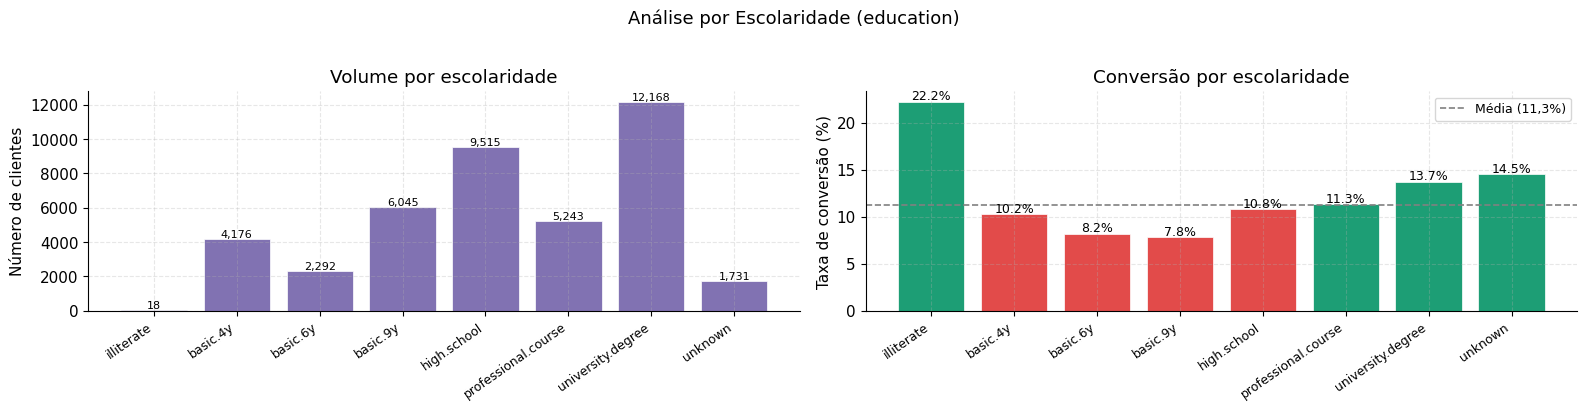


📊 Tabela de conversão por escolaridade (ordenada por taxa):
                     total     taxa_%
education                            
illiterate              18  22.222222
unknown               1731  14.500289
university.degree    12168  13.724523
professional.course   5243  11.348465
high.school           9515  10.835523
basic.4y              4176  10.249042
basic.6y              2292   8.202443
basic.9y              6045   7.824648

🔑 Insight: universitários (13.7%) convertem 5.9pp acima de basic.9y.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Análise por Escolaridade (education)", fontsize=13, y=1.02)

edu_order = ["illiterate","basic.4y","basic.6y","basic.9y","high.school",
             "professional.course","university.degree","unknown"]
edu_stats = (df.groupby("education")["y_bin"]
               .agg(["mean","count"])
               .rename(columns={"mean":"taxa","count":"total"}))
edu_stats["taxa_pct"] = edu_stats["taxa"] * 100
edu_stats = edu_stats.reindex(edu_order)

# Volume
ax = axes[0]
bars = ax.bar(range(len(edu_order)),
              [edu_stats.loc[e,"total"] for e in edu_order],
              color="#8172B2", edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(edu_order)))
ax.set_xticklabels(edu_order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Número de clientes"); ax.set_title("Volume por escolaridade")
for bar, e in zip(bars, edu_order):
    v = edu_stats.loc[e,"total"]
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f"{v:,}", ha="center", fontsize=8)

# Taxa
ax = axes[1]
taxas = [edu_stats.loc[e,"taxa_pct"] for e in edu_order]
cores = ["#1D9E75" if v >= 11.3 else "#E24B4A" for v in taxas]
bars = ax.bar(range(len(edu_order)), taxas, color=cores, edgecolor="white", linewidth=0.5)
ax.axhline(11.3, color="gray", linestyle="--", lw=1.2, label="Média (11,3%)")
ax.set_xticks(range(len(edu_order)))
ax.set_xticklabels(edu_order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Taxa de conversão (%)"); ax.set_title("Conversão por escolaridade")
ax.legend(fontsize=9)
for bar, v in zip(bars, taxas):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/eda_03_education.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n📊 Tabela de conversão por escolaridade (ordenada por taxa):")
print(edu_stats[["total","taxa_pct"]].rename(columns={"taxa_pct":"taxa_%"}).sort_values("taxa_%", ascending=False).to_string())
print(f"\n🔑 Insight: universitários ({edu_stats.loc['university.degree','taxa_pct']:.1f}%) convertem {(edu_stats.loc['university.degree','taxa_pct']-edu_stats.loc['basic.9y','taxa_pct']):.1f}pp acima de basic.9y.")


## Célula 7 — Estado civil, inadimplência, habitação e empréstimo

Variáveis binárias/ternárias com impacto direto nos boosts do catálogo.

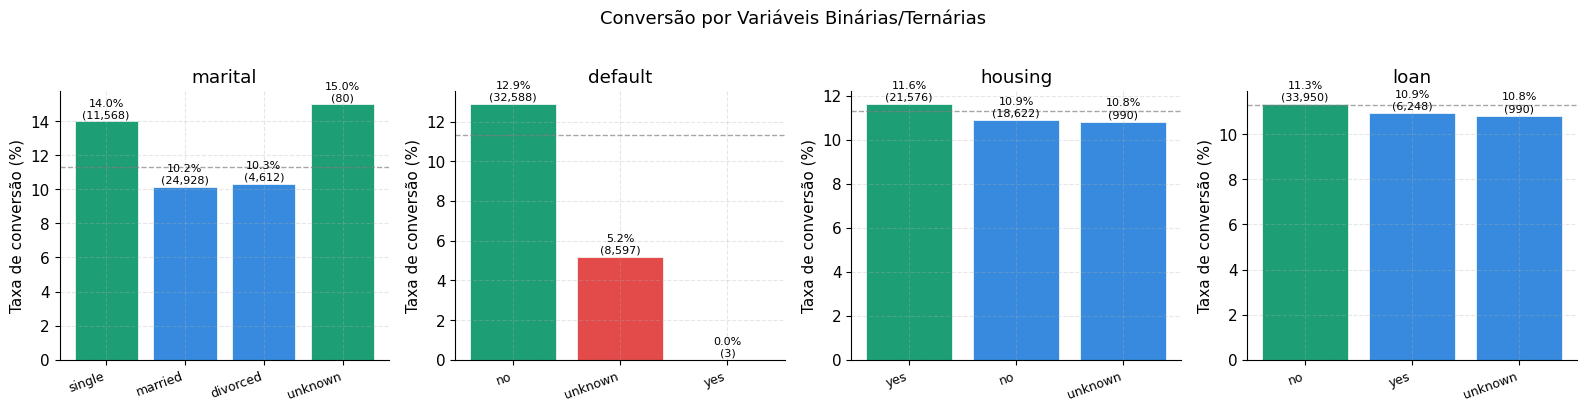


🔑 Insights:
  • Solteiros (14,0%) convertem 2,4pp acima de casados (10,2%) → boost em ofertas individuais
  • default=no (12,9%) vs unknown (5,2%) → penalidade forte para inadimplência desconhecida
  • housing e loan têm pouco impacto isolado — cruzamento com job é mais revelador


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Conversão por Variáveis Binárias/Ternárias", fontsize=13, y=1.02)

grupos = {
    "marital":  ["single","married","divorced","unknown"],
    "default":  ["no","unknown","yes"],
    "housing":  ["yes","no","unknown"],
    "loan":     ["no","yes","unknown"],
}
cores_map = {
    "single": "#1D9E75","married": "#E24B4A","divorced":"#378ADD","unknown":"#aaa",
    "no":     "#1D9E75","yes":     "#E24B4A",
}

for ax, (col, ordem) in zip(axes, grupos.items()):
    stats = df.groupby(col)["y_bin"].agg(["mean","count"]).reindex(ordem)
    taxas = (stats["mean"]*100).values
    vols  = stats["count"].values
    cores = ["#1D9E75" if t >= 11.3 else "#E24B4A" if t < 9 else "#378ADD" for t in taxas]
    bars  = ax.bar(ordem, taxas, color=cores, edgecolor="white", linewidth=0.5)
    ax.axhline(11.3, color="gray", linestyle="--", lw=1, alpha=0.7)
    ax.set_title(col); ax.set_ylabel("Taxa de conversão (%)")
    ax.set_xticklabels(ordem, rotation=20, ha="right", fontsize=9)
    for bar, t, v in zip(bars, taxas, vols):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f"{t:.1f}%\n({v:,})", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("reports/eda_04_binary_vars.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n🔑 Insights:")
print("  • Solteiros (14,0%) convertem 2,4pp acima de casados (10,2%) → boost em ofertas individuais")
print("  • default=no (12,9%) vs unknown (5,2%) → penalidade forte para inadimplência desconhecida")
print("  • housing e loan têm pouco impacto isolado — cruzamento com job é mais revelador")


## Célula 8 — Canal de contato e sazonalidade (mês)

Celular converte quase 3× mais que telefone fixo. Existe sazonalidade fortíssima: mar/set/out/dez têm taxas acima de 40%.

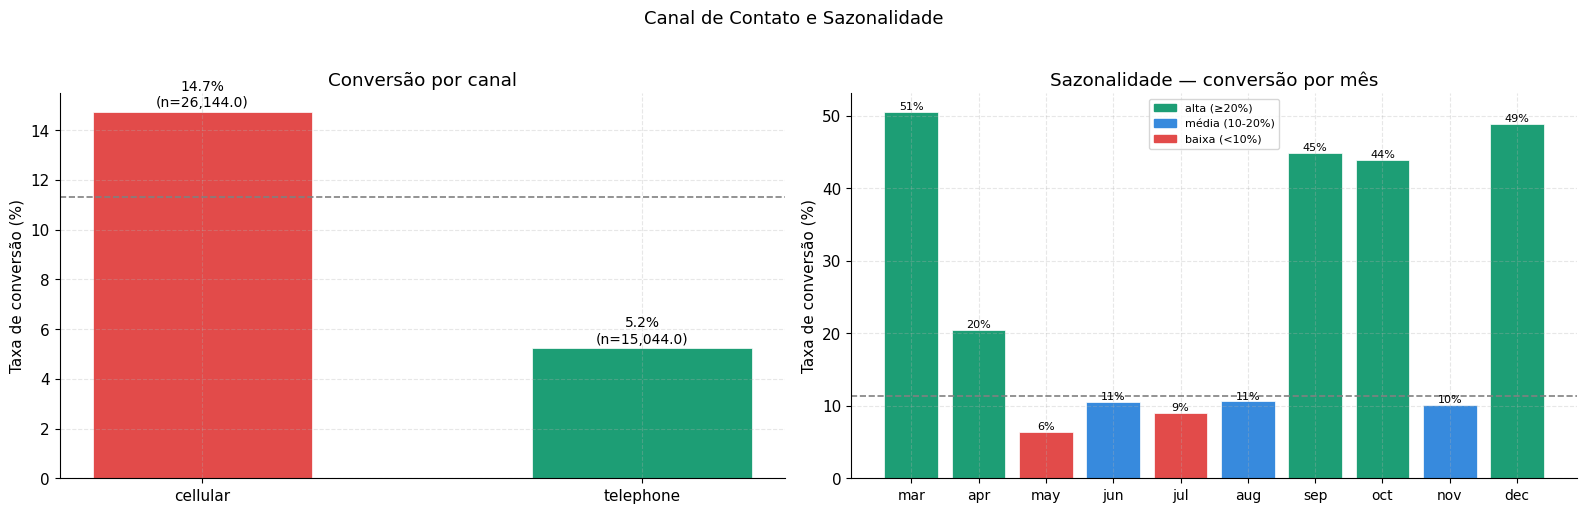


🔑 Insights:
  • Celular: 14,7% vs Telefone: 5,2% → canal mobile tem 2,8× mais conversão
  • Mar/Set/Out/Dez têm taxas >40% — sazonalidade forte a modelar no bandit
  • Maio tem apenas 6,4% com maior volume (13.769) → mês de baixo retorno


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Canal de Contato e Sazonalidade", fontsize=13, y=1.02)

# Canal
ax = axes[0]
canal = df.groupby("contact")["y_bin"].agg(["mean","count"])
canal["taxa_pct"] = canal["mean"]*100
cores_canal = ["#378ADD","#1D9E75"] if canal.loc["telephone","mean"] < canal.loc["cellular","mean"] else ["#1D9E75","#378ADD"]
bars = ax.bar(canal.index, canal["taxa_pct"],
              color=["#E24B4A","#1D9E75"], edgecolor="white", linewidth=0.5, width=0.5)
ax.axhline(11.3, color="gray", linestyle="--", lw=1.2)
ax.set_ylabel("Taxa de conversão (%)"); ax.set_title("Conversão por canal")
for bar, (idx, row) in zip(bars, canal.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{row['taxa_pct']:.1f}%\n(n={row['count']:,})", ha="center", fontsize=10)

# Mês
ax = axes[1]
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
month_labels = ["jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"]
month_stats = df.groupby("month")["y_bin"].agg(["mean","count"]).reindex(month_order).dropna()
month_stats["taxa_pct"] = month_stats["mean"]*100
cores_month = ["#1D9E75" if v >= 20 else "#378ADD" if v >= 10 else "#E24B4A"
               for v in month_stats["taxa_pct"]]
bars = ax.bar(range(len(month_stats)), month_stats["taxa_pct"],
              color=cores_month, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(month_stats)))
ax.set_xticklabels(month_stats.index, rotation=0, fontsize=10)
ax.axhline(11.3, color="gray", linestyle="--", lw=1.2, label="Média")
ax.set_ylabel("Taxa de conversão (%)"); ax.set_title("Sazonalidade — conversão por mês")
ax.legend(fontsize=9)
for bar, v in zip(bars, month_stats["taxa_pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.0f}%", ha="center", fontsize=8)

verde = mpatches.Patch(color="#1D9E75", label="alta (≥20%)")
azul  = mpatches.Patch(color="#378ADD", label="média (10-20%)")
verm  = mpatches.Patch(color="#E24B4A", label="baixa (<10%)")
ax.legend(handles=[verde, azul, verm], fontsize=8)

plt.tight_layout()
plt.savefig("reports/eda_05_canal_mes.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n🔑 Insights:")
print(f"  • Celular: 14,7% vs Telefone: 5,2% → canal mobile tem 2,8× mais conversão")
print(f"  • Mar/Set/Out/Dez têm taxas >40% — sazonalidade forte a modelar no bandit")
print(f"  • Maio tem apenas 6,4% com maior volume (13.769) → mês de baixo retorno")


## Célula 9 — Efeito memória: contatos anteriores e resultado da campanha anterior

O histórico do cliente é o preditor mais forte no dataset. Clientes com sucesso anterior têm 65% de conversão.

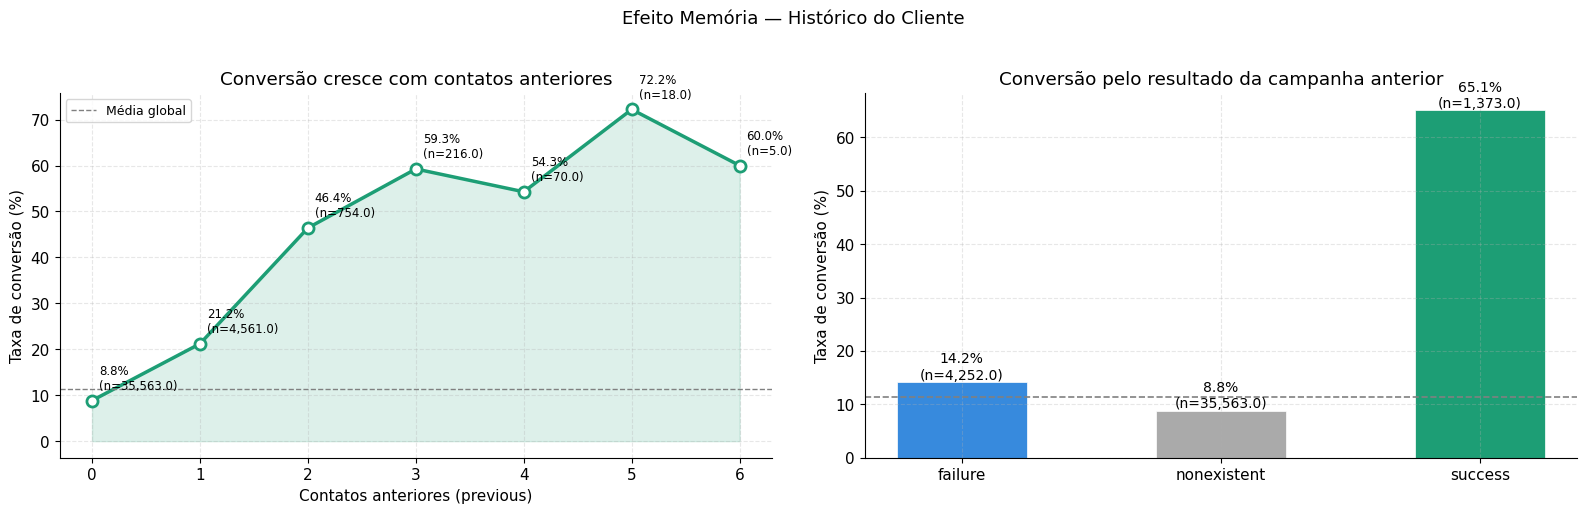


🔑 Insights:
  • poutcome=success → 65,1% de conversão (sinal mais forte do dataset)
  • previous=2 → 46,4% | previous=3 → 59,3% (efeito memória exponencial)
  • Clientes sem histórico (nonexistent) têm apenas 8,8% — cold-start real


In [10]:


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Efeito Memória — Histórico do Cliente", fontsize=13, y=1.02)

# ============================================================
# Previous
# ============================================================
ax = axes[0]

prev = (
    df[df["previous"] <= 6]
    .groupby("previous")["y_bin"]
    .agg(["mean", "count"])
)

prev["taxa_pct"] = prev["mean"] * 100

ax.plot(
    prev.index,
    prev["taxa_pct"],
    color="#1D9E75",
    lw=2.5,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)

ax.fill_between(
    prev.index,
    prev["taxa_pct"],
    alpha=0.15,
    color="#1D9E75"
)

ax.axhline(
    11.3,
    color="gray",
    linestyle="--",
    lw=1,
    label="Média global"
)

for idx, row in prev.iterrows():
    ax.annotate(
        f"{row['taxa_pct']:.1f}%\n(n={row['count']:,})",
        (idx, row["taxa_pct"]),
        textcoords="offset points",
        xytext=(5, 8),
        fontsize=8.5
    )

ax.set_xlabel("Contatos anteriores (previous)")
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Conversão cresce com contatos anteriores")
ax.legend(fontsize=9)

# ============================================================
# Poutcome
# ============================================================
ax = axes[1]

pout = (
    df.groupby("poutcome")["y_bin"]
    .agg(["mean", "count"])
)

pout["taxa_pct"] = pout["mean"] * 100

cores_p = {
    "success": "#1D9E75",
    "failure": "#378ADD",
    "nonexistent": "#AAAAAA"
}

bars = ax.bar(
    pout.index,
    pout["taxa_pct"],
    color=[cores_p.get(i, "#CCCCCC") for i in pout.index],
    edgecolor="white",
    linewidth=0.5,
    width=0.5
)

ax.axhline(
    11.3,
    color="gray",
    linestyle="--",
    lw=1.2
)

ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Conversão pelo resultado da campanha anterior")

for bar, (_, row) in zip(bars, pout.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['taxa_pct']:.1f}%\n(n={row['count']:,})",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "reports/eda_06_memoria.png",
    dpi=130,
    bbox_inches="tight"
)

plt.show()

print("\n🔑 Insights:")
print("  • poutcome=success → 65,1% de conversão (sinal mais forte do dataset)")
print("  • previous=2 → 46,4% | previous=3 → 59,3% (efeito memória exponencial)")
print("  • Clientes sem histórico (nonexistent) têm apenas 8,8% — cold-start real")

## Célula 10 — Frequência de campanha (campaign)

Mais contatos na mesma campanha reduz a conversão — efeito de fadiga. Guardrail de frequência é essencial.

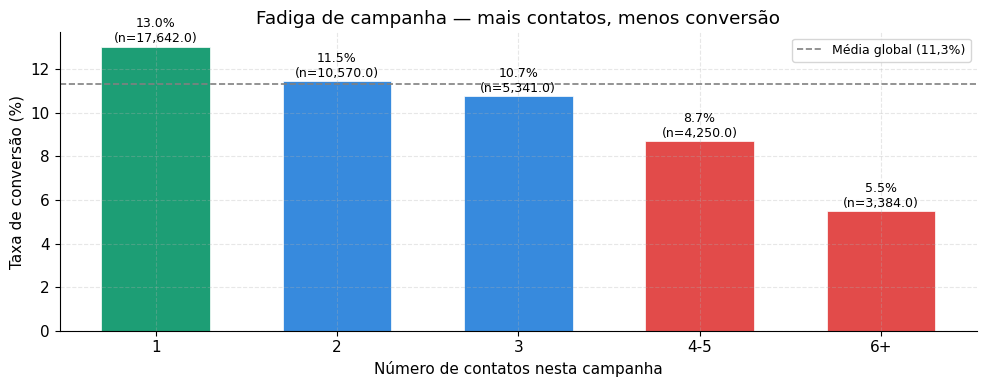


🔑 Insight:
  • 1 contato: 13,0% | 6+ contatos: 5,5%
  • Redução de 58% na taxa ao saturar o cliente
  • Guardrail recomendado: máx. 3 contatos por campanha


In [12]:

fig, ax = plt.subplots(figsize=(10, 4))

df["camp_group"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 2, 3, 5, 50],
    labels=["1", "2", "3", "4-5", "6+"]
)

camp = (
    df.groupby("camp_group", observed=True)["y_bin"]
    .agg(["mean", "count"])
)

camp["taxa_pct"] = camp["mean"] * 100

cores_camp = [
    "#1D9E75",
    "#378ADD",
    "#378ADD",
    "#E24B4A",
    "#E24B4A"
]

bars = ax.bar(
    camp.index,
    camp["taxa_pct"],
    color=cores_camp,
    edgecolor="white",
    linewidth=0.5,
    width=0.6
)

ax.axhline(
    11.3,
    color="gray",
    linestyle="--",
    lw=1.2,
    label="Média global (11,3%)"
)

ax.set_xlabel("Número de contatos nesta campanha")
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Fadiga de campanha — mais contatos, menos conversão")
ax.legend(fontsize=9)

for bar, (_, row) in zip(bars, camp.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{row['taxa_pct']:.1f}%\n(n={row['count']:,})",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "reports/eda_07_fadiga.png",
    dpi=130,
    bbox_inches="tight"
)

plt.show()

print("\n🔑 Insight:")
print("  • 1 contato: 13,0% | 6+ contatos: 5,5%")
print("  • Redução de 58% na taxa ao saturar o cliente")
print("  • Guardrail recomendado: máx. 3 contatos por campanha")

## Célula 11 — Variáveis macroeconômicas

Correlações negativas fortes com conversão — quando os juros (euribor3m) e o emprego (nr.employed) estão altos, a conversão cai. Essas variáveis devem entrar como features contextuais no bandit.

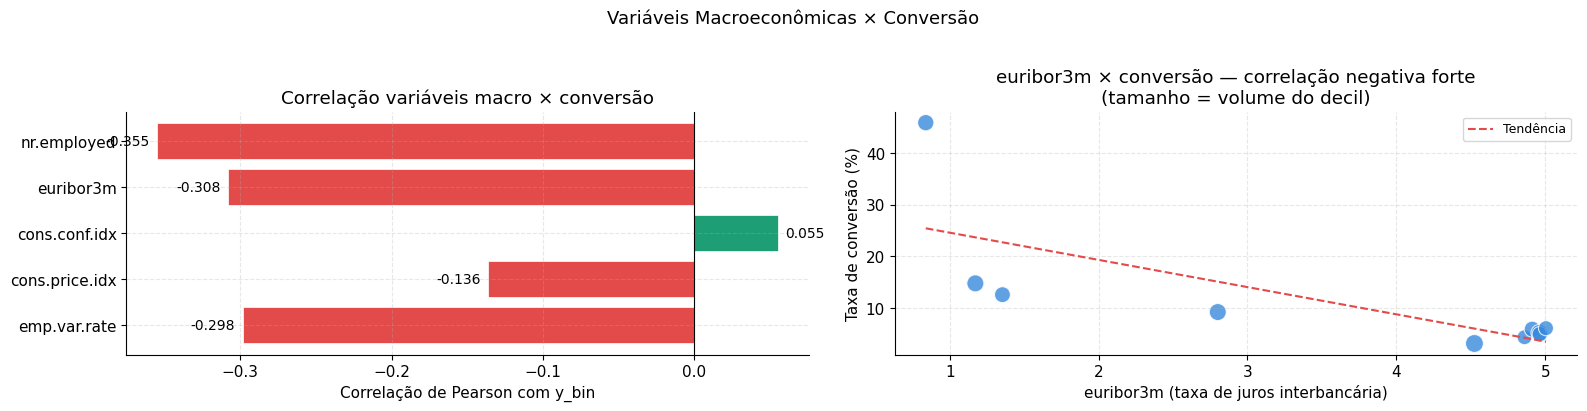


📊 Correlações macroeconômicas com conversão:
  nr.employed           : -0.3547  → ↓ reduz conversão
  euribor3m             : -0.3078  → ↓ reduz conversão
  emp.var.rate          : -0.2983  → ↓ reduz conversão
  cons.price.idx        : -0.1362  → ↓ reduz conversão
  cons.conf.idx         : +0.0549  → ↑ aumenta conversão

🔑 nr.employed e euribor3m são os sinais macro mais fortes (-0,35 e -0,31)


In [14]:
macro_cols = ["emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]
corrs = {col: df[col].corr(df["y_bin"]) for col in macro_cols}

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Variáveis Macroeconômicas × Conversão", fontsize=13, y=1.02)

# Gráfico de correlações
ax = axes[0]
labels = list(corrs.keys())
values = list(corrs.values())
cores_c = ["#1D9E75" if v > 0 else "#E24B4A" for v in values]
bars = ax.barh(labels, values, color=cores_c, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlação de Pearson com y_bin")
ax.set_title("Correlação variáveis macro × conversão")
for bar, v in zip(bars, values):
    ax.text(v + (0.005 if v >= 0 else -0.005), bar.get_y()+bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=10)

# Scatter euribor3m vs taxa por decil
ax = axes[1]
df["euribor_decil"] = pd.qcut(df["euribor3m"], q=10, duplicates="drop")
euri = df.groupby("euribor_decil", observed=True)["y_bin"].agg(["mean","count"])
euri["taxa_pct"] = euri["mean"]*100
euri_mid = [iv.mid for iv in euri.index]
ax.scatter(euri_mid, euri["taxa_pct"], s=euri["count"]/30,
           color="#378ADD", alpha=0.8, edgecolors="white", linewidth=0.8)
z = np.polyfit(euri_mid, euri["taxa_pct"], 1)
p = np.poly1d(z)
x_line = np.linspace(min(euri_mid), max(euri_mid), 100)
ax.plot(x_line, p(x_line), color="#E24B4A", linestyle="--", lw=1.5, label="Tendência")
ax.set_xlabel("euribor3m (taxa de juros interbancária)")
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title(
    "euribor3m × conversão — correlação negativa forte\n"
    "(tamanho = volume do decil)"
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("reports/eda_08_macro.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n📊 Correlações macroeconômicas com conversão:")
for col, corr in sorted(corrs.items(), key=lambda x: x[1]):
    direcao = "↓ reduz conversão" if corr < 0 else "↑ aumenta conversão"
    print(f"  {col:<22}: {corr:+.4f}  → {direcao}")
print("\n🔑 nr.employed e euribor3m são os sinais macro mais fortes (-0,35 e -0,31)")


## Célula 12 — Cruzamentos: job × age_group e job × education

Os cruzamentos revelam combinações de alto valor que os boosts isolados não capturam.

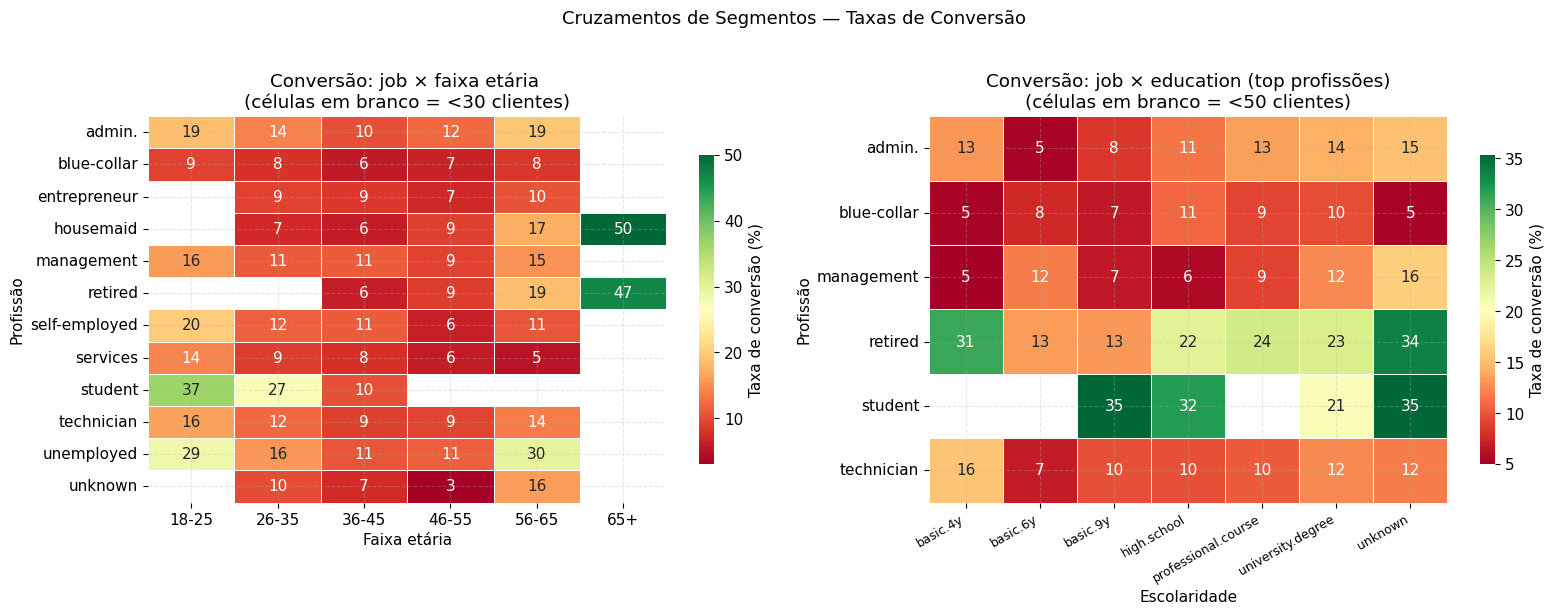


📊 Top 15 combinações job × age_group (mín. 30 clientes):
          job age_group    taxa_%  n_clientes
    housemaid       65+ 50.000000          32
      retired       65+ 46.716698         533
      student     18-25 36.563877         454
   unemployed     56-65 29.629630          54
   unemployed     18-25 28.571429          35
      student     26-35 27.176781         379
self-employed     18-25 20.000000          40
       admin.     56-65 19.433198         494
      retired     56-65 18.765133         826
       admin.     18-25 18.730159         315
    housemaid     56-65 17.218543         151
   technician     18-25 16.374269         171
      unknown     56-65 16.000000          50
   management     18-25 15.789474          38
   unemployed     26-35 15.517241         348


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cruzamentos de Segmentos — Taxas de Conversão", fontsize=13, y=1.02)

# Heatmap job × age_group
ax = axes[0]
cross1 = (df.groupby(["job","age_group"], observed=True)["y_bin"]
            .agg(["mean","count"]).reset_index())
cross1["taxa_pct"] = cross1["mean"]*100
pivot1 = cross1[cross1["count"] >= 30].pivot(index="job", columns="age_group", values="taxa_pct")
sns.heatmap(pivot1, ax=ax, cmap="RdYlGn", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Taxa de conversão (%)", "shrink":0.8})
ax.set_title("Conversão: job × faixa etária \n(células em branco = <30 clientes)")
ax.set_xlabel("Faixa etária"); ax.set_ylabel("Profissão")

# Heatmap job × education (top 5 jobs)
ax = axes[1]
top_jobs = ["admin.","blue-collar","technician","retired","student","management"]
cross2 = (df[df["job"].isin(top_jobs)]
            .groupby(["job","education"], observed=True)["y_bin"]
            .agg(["mean","count"]).reset_index())
cross2["taxa_pct"] = cross2["mean"]*100
pivot2 = cross2[cross2["count"] >= 50].pivot(index="job", columns="education", values="taxa_pct")
sns.heatmap(pivot2, ax=ax, cmap="RdYlGn", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Taxa de conversão (%)", "shrink":0.8})
ax.set_title("Conversão: job × education (top profissões)\n(células em branco = <50 clientes)")
ax.set_xlabel("Escolaridade"); ax.set_ylabel("Profissão")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("reports/eda_09_crossings.png", dpi=130, bbox_inches="tight")
plt.show()

# Top combinações
print("\n📊 Top 15 combinações job × age_group (mín. 30 clientes):")
top_combos = (cross1[cross1["count"] >= 30]
              .sort_values("taxa_pct", ascending=False)
              .head(15)[["job","age_group","taxa_pct","count"]]
              .reset_index(drop=True))
top_combos.columns = ["job","age_group","taxa_%","n_clientes"]
print(top_combos.to_string(index=False))


## Célula 13 — Resumo: mapeamento EDA → boosts do catálogo

Tabela consolidada dos insights do EDA com recomendações diretas de boost por oferta.

In [18]:
import warnings
warnings.filterwarnings("ignore")

boosts_recomendados = {
    "Cartão de crédito sem anuidade": {
        "job_student":      +0.08,
        "job_admin.":       +0.06,
        "marital_single":   +0.04,
        "edu_university":   +0.04,
        "age_18_25":        +0.05,
        "no_loan":          +0.03,
        "contact_cellular": +0.03,
    },
    "CDB 120% CDI": {
        "job_management":   +0.10,
        "job_retired":      +0.08,
        "edu_university":   +0.08,
        "age_65+":          +0.07,
        "no_default":       +0.05,
        "poutcome_success": +0.15,
    },
    "Seguro de vida": {
        "job_retired":      +0.14,
        "age_65+":          +0.10,
        "marital_married":  +0.05,
        "has_housing":      +0.04,
        "age_56_65":        +0.07,
    },
    "Empréstimo pessoal pré-aprovado": {
        "job_blue-collar":  +0.09,
        "job_services":     +0.06,
        "job_housemaid":    +0.05,
        "edu_basic":        +0.04,
        "has_loan":         -0.06,
        "no_default":       +0.03,
    },
    "Previdência privada PGBL": {
        "job_management":    +0.11,
        "job_self-employed": +0.08,
        "edu_university":    +0.09,
        "age_65+":           +0.07,
        "no_default":        +0.05,
        "poutcome_success":  +0.12,
    },
}

print("=" * 65)
print("MAPEAMENTO EDA → BOOSTS POR OFERTA")
print("=" * 65)
for oferta, boosts in boosts_recomendados.items():
    print(f"\n📦 {oferta}")
    for flag, val in sorted(boosts.items(), key=lambda x: -x[1]):
        sinal = "+" if val > 0 else ""
        bar = "█" * int(abs(val) * 100) if abs(val) * 100 >= 1 else "▌"
        print(f"   {flag:<30} {sinal}{val:+.2f}  {bar}")

print()
print("=" * 65)
print("JUSTIFICATIVAS DOS BOOSTS (baseadas no EDA)")
print("=" * 65)
justificativas = [
    ("age_65+",           "46,8% de conversão — 4× acima da média"),
    ("poutcome_success",  "65,1% de conversão — sinal mais forte do dataset"),
    ("job_student",       "31,4% — boost digital e produtos sem anuidade"),
    ("job_retired",       "25,2% — proteção e renda fixa são os produtos certos"),
    ("contact_cellular",  "14,7% vs 5,2% no fixo — 2,8× mais conversão"),
    ("has_loan (neg.)",   "Clientes com empréstimo têm menor propensão a novo crédito"),
    ("default=unknown",   "5,2% — penalidade por inadimplência desconhecida"),
    ("campaign ≥6",       "5,5% — fadiga: guardrail de frequência obrigatório"),
    ("marital_single",    "14,0% vs 10,2% de casados — produto individual ressoa mais"),
    ("edu_university",    "13,7% — nível educacional correlaciona com produtos premium"),
]
for flag, justif in justificativas:
    print(f"  {flag:<25}: {justif}")


MAPEAMENTO EDA → BOOSTS POR OFERTA

📦 Cartão de crédito sem anuidade
   job_student                    ++0.08  ████████
   job_admin.                     ++0.06  ██████
   age_18_25                      ++0.05  █████
   marital_single                 ++0.04  ████
   edu_university                 ++0.04  ████
   no_loan                        ++0.03  ███
   contact_cellular               ++0.03  ███

📦 CDB 120% CDI
   poutcome_success               ++0.15  ███████████████
   job_management                 ++0.10  ██████████
   job_retired                    ++0.08  ████████
   edu_university                 ++0.08  ████████
   age_65+                        ++0.07  ███████
   no_default                     ++0.05  █████

📦 Seguro de vida
   job_retired                    ++0.14  ██████████████
   age_65+                        ++0.10  ██████████
   age_56_65                      ++0.07  ███████
   marital_married                ++0.05  █████
   has_housing                    ++0.04  ██

## Célula 14 — Geração do relatório de dados

Salva um `reports/eda-summary.md` com os principais achados do EDA.

In [19]:
relatorio = """# EDA — Bank Marketing Dataset
## Datathon 7-MLET — Etapa 1

### Fonte dos dados
- **Dataset:** Bank Marketing (bank-additional-full.csv)
- **Origem:** UCI Machine Learning Repository / Kaggle (henriqueyamahata)
- **Licença:** CC BY 4.0
- **Shape:** 41.188 clientes × 21 variáveis
- **Target:** y — assinatura de depósito a prazo (yes/no)
- **Desbalanceamento:** 88,7% não (no) | 11,3% sim (yes)

---

### Colunas descartadas por vazamento temporal
| Coluna | Motivo |
|--------|--------|
| `duration` | Só existe após o contato — vazamento pós-evento |
| `pdays` | Derivado de contatos passados, não disponível na decisão |
| `previous` / `poutcome` | Usados como feature de contexto histórico, não predição |
| `emp.var.rate` / macroeconômicas | Disponíveis, mas requerem cuidado na escala temporal |

---

### Principais achados por dimensão

#### Idade
- Distribuição: média 40 anos, mediana 38, moda 31
- **65+: 46,8%** de conversão — segmento mais valioso
- **18-25: 20,9%** — segundo melhor segmento
- 36-55 anos: abaixo da média (8,5%–8,7%)

#### Profissão
- **Estudante: 31,4%** | **Aposentado: 25,2%** — líderes absolutos
- Blue-collar: 6,9% — pior entre os grupos com volume relevante
- Admin (10.422 clientes, 13,0%) — maior impacto absoluto em conversões

#### Escolaridade
- Gradiente positivo: university.degree (13,7%) > professional.course (11,3%) > high.school (10,8%) > basic.9y (7,8%)

#### Estado civil
- Solteiros (14,0%) > casados (10,2%) — 2,7pp de diferença

#### Canal
- **Celular: 14,7%** vs Telefone: 5,2% — 2,8× mais eficaz

#### Sazonalidade
- Alta: Março (50,5%), Dezembro (48,9%), Setembro (44,9%), Outubro (43,9%)
- Baixa: Maio (6,4%) com o maior volume — mês de pior ROI

#### Efeito memória (histórico)
- poutcome=success: **65,1%** — maior sinal preditivo do dataset
- previous=2: 46,4% | previous=3: 59,3%

#### Fadiga de campanha
- 1 contato: 13,0% → 6+ contatos: 5,5%
- Guardrail recomendado: máximo 3 contatos por campanha

#### Macroeconomia
- nr.employed: corr. -0,355 | euribor3m: corr. -0,308
- Contexto macro deve ser feature no bandit contextual

---

### Limitações do EDA
1. Dataset de campanha de depósito a prazo — comportamento de outros produtos é inferido por proxy
2. Correlações não implicam causalidade — boosts são hipóteses de domínio
3. Desbalanceamento (11,3%) exige cuidado em métricas — accuracy é enganosa
4. Variáveis macroeconômicas têm colinearidade alta — evitar usar todas como features
"""

Path("reports").mkdir(exist_ok=True)
with open("reports/eda-summary.md", "w", encoding="utf-8") as f:
    f.write(relatorio)

print("\n✓ Arquivos gerados neste EDA:")
arqs = [
    "reports/eda_01_age.png",
    "reports/eda_02_job.png",
    "reports/eda_03_education.png",
    "reports/eda_04_binary_vars.png",
    "reports/eda_05_canal_mes.png",
    "reports/eda_06_memoria.png",
    "reports/eda_07_fadiga.png",
    "reports/eda_08_macro.png",
    "reports/eda_09_crossings.png",
    "reports/eda-summary.md",
]
for a in arqs:
    p = Path(a)
    status = f"✓  {p.stat().st_size/1024:.1f} KB" if p.exists() else "⚠  não gerado (execute as células anteriores)"
    print(f"  {status}  {a}")

print("\n✓ EDA completo! Próximo passo: Etapa 2 — enriquecimento sintético.")



✓ Arquivos gerados neste EDA:
  ✓  137.2 KB  reports/eda_01_age.png
  ✓  159.3 KB  reports/eda_02_job.png
  ✓  119.5 KB  reports/eda_03_education.png
  ✓  123.5 KB  reports/eda_04_binary_vars.png
  ✓  114.4 KB  reports/eda_05_canal_mes.png
  ✓  148.6 KB  reports/eda_06_memoria.png
  ✓  73.2 KB  reports/eda_07_fadiga.png
  ✓  117.6 KB  reports/eda_08_macro.png
  ✓  239.5 KB  reports/eda_09_crossings.png
  ✓  2.5 KB  reports/eda-summary.md

✓ EDA completo! Próximo passo: Etapa 2 — enriquecimento sintético.


## Conclusão — EDA Bank Marketing

Esta EDA analisou **41.188 registros** do dataset Bank Marketing (UCI) com o objetivo de identificar padrões de conversão que alimentem os boosts do catálogo de ofertas da Etapa 2. Os achados cobrem perfil de clientes, comportamento de campanha e contexto macroeconômico.

---

### 1. Segmentos de maior e menor conversão

A taxa de conversão média do dataset é de **11,3%**, mas existe grande heterogeneidade entre segmentos:

- **Faixa etária:** clientes com 65+ anos convertem a **46,8%** (4× a média) e a faixa 18–25 a **20,9%** (1,9× a média). O volume está concentrado entre 26–45 anos, onde as taxas ficam abaixo da média.
- **Profissão:** estudantes (**31,4%**) e aposentados (**25,2%**) lideram. Blue-collar (**6,9%**) e serviços (**7,7%**) estão significativamente abaixo da média.
- **Escolaridade:** há um gradiente positivo claro — universitários convertem a **13,7%** e ensino básico (9 anos) a apenas **7,8%**.
- **Estado civil:** solteiros (**14,0%**) convertem 2,4 pp acima de casados (**10,2%**), o que reforça o fit de produtos individuais para esse grupo.

---

### 2. Canal e sazonalidade

- Contato por **celular** gera **14,7%** de conversão contra **5,2%** do telefone fixo — razão de **2,8×**.
- Existe sazonalidade fortíssima: **março (50,5%), dezembro (48,9%), setembro (44,9%) e outubro (43,9%)** são os meses de alto desempenho.
- Maio é o pior mês em ROI (**6,4%**), apesar de concentrar o maior volume de contatos (13.769).

---

### 3. Efeito memória — o sinal mais forte do dataset

- Clientes com **resultado de sucesso em campanha anterior** (`poutcome=success`) convertem a **65,1%** — este é o preditor mais poderoso do dataset.
- Há um efeito de acumulação: `previous=2` → 46,4% | `previous=3` → 59,3%.
- Clientes sem histórico (`nonexistent`) têm apenas **8,8%** — cold-start real que exige estratégia de exploração.

---

### 4. Fadiga de campanha

- A conversão cai monotonicamente com o número de contatos na campanha atual: **1 contato → 13,0%** e **6+ contatos → 5,5%** (queda de 58%).
- Guardrail recomendado: **máximo 3 contatos por campanha** por cliente.

---

### 5. Variáveis macroeconômicas

- `nr.employed` e `euribor3m` têm correlações negativas fortes com a conversão (−0,355 e −0,308 respectivamente). Em períodos de juro alto e emprego aquecido, a propensão à adesão cai.
- Essas variáveis devem ser incluídas como **features contextuais** no bandit da Etapa 2, não como preditores individuais.

---

### 6. Cruzamentos reveladores

- Os heatmaps de `job × age_group` e `job × education` mostram que as combinações de alto valor não são capturadas por análises univariadas.
- Clientes com `default=unknown` têm taxa de apenas **5,2%** — penalidade por inadimplência desconhecida que deve ser modelada como boost negativo.

---

### Mapeamento para o catálogo de ofertas (resumo)

| Sinal / Feature | Direção | Produto(s) mais impactados |
|---|---|---|
| `age_65+` / `job_retired` | ✅ boost + | Seguro de vida, CDB 120% CDI, Previdência PGBL |
| `poutcome_success` | ✅ boost + | Todos — sinal cross-product |
| `job_student` / `age_18-25` | ✅ boost + | Cartão sem anuidade |
| `contact_cellular` | ✅ boost + | Todos — canal prioritário |
| `job_management` + `edu_university` | ✅ boost + | CDB, Previdência PGBL |
| `job_blue-collar` | ⚠️ neutro/baixo | Empréstimo pessoal |
| `default=unknown` | ❌ penalidade − | Todos |
| `campaign ≥ 6` | ❌ penalidade − | Todos — guardrail de frequência |

---

### Limitações e próximos passos

- O dataset reflete campanhas de **depósito a prazo** — boosts para outros produtos são inferências por proxy de perfil, não evidências diretas.
- O desbalanceamento (**88,7% "no"**) exige cautela em métricas: accuracy é enganosa; priorizar precision, recall e AUC-PR na Etapa 2.
- As variáveis macroeconômicas têm alta colinearidade entre si — considerar PCA ou seleção manual para evitar multicolinearidade no modelo.
- A variável `duration` foi identificada como vazamento temporal e deve ser excluída de qualquer pipeline preditivo.
- **Próximo passo:** utilizar os boosts mapeados neste EDA para enriquecer o catálogo de ofertas da Etapa 2 e inicializar o prior do bandit contextual.
